<a href="https://colab.research.google.com/github/pedroyoshikadogarcia/Checkpoint-2-SERS-02.2026/blob/main/AULA_07_Regress%C3%A3o_Linear_com_Dados_de_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## Integrantes

Eduardo Novaki Santos Coelho RM: 572649

Gabriel dos Santos Siqueira RM: 572200

Pedro Andreassa Zamai RM: 569318

Pedro Yoshikado Garcia RM: 570449

Rafael Ferreirinha Quaresma RM: 571949

Thiago Maluf Hofmann RM: 569852


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [1]:
# Importe aqui as bibliotecas necessárias
# Manipulação de tabelas e matrizes/vetores
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regressão linear
from sklearn.linear_model import LinearRegression
# Ferramenta para separação dos dados de treino e teste
# X_train, X_test, y_train, y_test
from sklearn.model_selection import train_test_split
# Avaliação
# Métricas de avaliação
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [2]:
dados = pd.read_csv('http://raw.githubusercontent.com/pedroyoshikadogarcia/Checkpoint-2-SERS-02.2026/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Registro da análise inicial

**Quantidade de linhas: 10000**
**Quantidade de colunas: 14**  
**Existem valores ausentes? 0**  
**Observações importantes sobre o dataset: As colunas tau1 a tau4 (tempo de atraso), p1 a p4 (perfil de potência) e g1 a g4 (constante de amortecimento) são as features numéricas. A coluna stab é a estabilidade numérica (target principal), e stabf é a classe categórica (stable / unstable), que não será usada na regressão linear.**

In [3]:
print("Quantidade de linhas:", dados.shape[0])
print("Quantidade de colunas:", dados.shape[1])
print("Valores ausentes:", dados.isnull().sum().sum())
display(dados.info())
display(dados.describe())

Quantidade de linhas: 10000
Quantidade de colunas: 14
Valores ausentes: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


None

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [4]:
y = dados['stab']
print(y.head())

0    0.055347
1   -0.005957
2    0.003471
3    0.028871
4    0.049860
Name: stab, dtype: float64


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

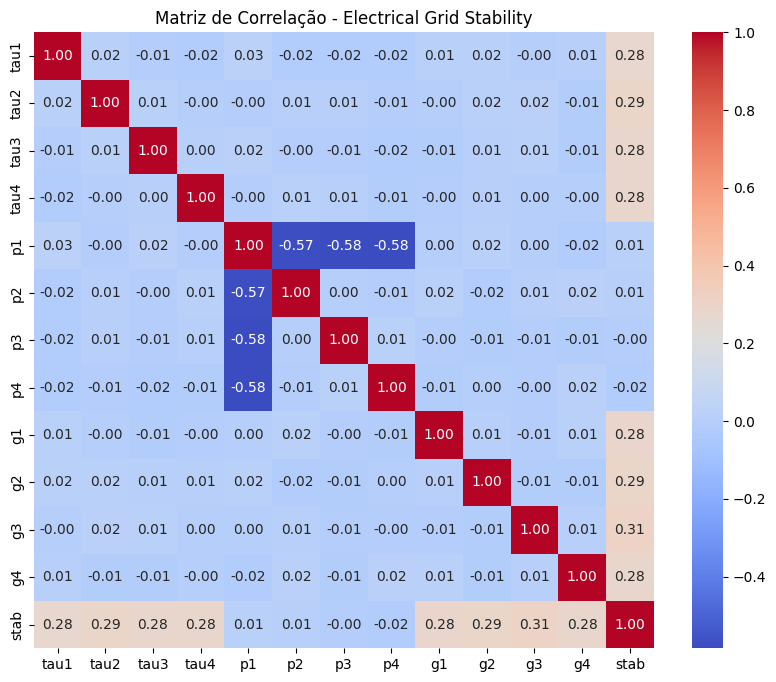

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(dados.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - Electrical Grid Stability")
plt.show()

## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

Variáveis selecionadas e suas correlações:
g3: 0.3082
g2: 0.2936
tau2: 0.2910
g1: 0.2828
tau3: 0.2807


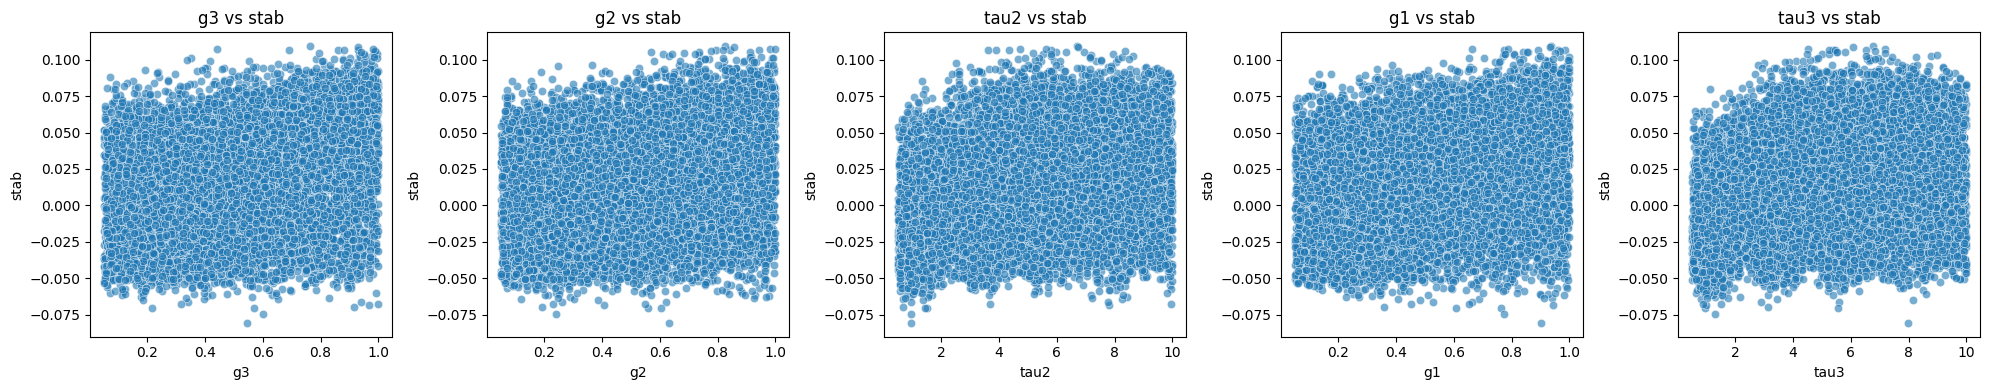

In [6]:
# 1. Calcula a correlação com stab, desconsiderando a própria coluna
correlacoes = dados.select_dtypes(include=[np.number]).corr()['stab'].drop('stab')

# 2. Usa o valor absoluto para pegar o top 5 e preserva os sinais originais
cinco_variaveis = correlacoes.abs().nlargest(5).index.tolist()
valores_correlacao = correlacoes[cinco_variaveis]

print("Variáveis selecionadas e suas correlações:")
for var in cinco_variaveis:
    print(f"{var}: {correlacoes[var]:.4f}")

# 3. Plota os gráficos de dispersão
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, var in enumerate(cinco_variaveis):
    sns.scatterplot(data=dados, x=var, y='stab', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{var} vs stab')
plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3| 0.3082 |
| 2 | g2 | 0.2936 |
| 3 |  tau2| 0.2910 |
| 4 |  g1| 0.2828 |
| 5 |  tau3| 0.2807 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta:  A variável g3, com uma correlação de aproximadamente 0.3082.

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Os gráficos mostram uma dispersão considerável dos pontos em torno de uma tendência linear fraca a moderada. Isso indica que, embora exista correlação matemática individual, apenas uma variável isolada não consegue explicar com alta precisão o comportamento completo da estabilidade (stab).

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [7]:
X = dados[cinco_variaveis]
display(X.head())
display(y.head())

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [8]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
print("Registros em X_treino:", X_treino.shape[0])
print("Registros em X_teste:", X_teste.shape[0])

Registros em X_treino: 8000
Registros em X_teste: 2000


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [9]:
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)
y_previsao_1 = modeloLR.predict(X_teste)

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [10]:
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f"R² Modelo 1: {r2_modelo_1:.4f}")
print(f"MAE Modelo 1: {mae_modelo_1:.4f}")
print(f"MSE Modelo 1: {mse_modelo_1:.4f}")

R² Modelo 1: 0.4018
MAE Modelo 1: 0.0233
MSE Modelo 1: 0.0008


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [11]:
X_tau_g = dados.filter(regex='^(tau|g)')
print("Colunas selecionadas:", X_tau_g.columns.tolist())

Colunas selecionadas: ['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [12]:
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)
print("Mesmo índice em y_teste e y2_teste?", (y_teste.index == y2_teste.index).all())

Mesmo índice em y_teste e y2_teste? True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [13]:
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f"R² Modelo 2: {r2_modelo_2:.4f}")
print(f"MAE Modelo 2: {mae_modelo_2:.4f}")
print(f"MSE Modelo 2: {mse_modelo_2:.4f}")

R² Modelo 2: 0.6452
MAE Modelo 2: 0.0176
MSE Modelo 2: 0.0005


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [14]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1 (Top 5 Correlações)', 'Modelo 2 (Todas Tau e G)'],
    'Variáveis utilizadas': [str(cinco_variaveis), str(X_tau_g.columns.tolist())],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})
display(comparacao_modelos)

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1 (Top 5 Correlações),"['g3', 'g2', 'tau2', 'g1', 'tau3']",0.401770,0.023310,0.000811
1,Modelo 2 (Todas Tau e G),"['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', '...",0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

/tmp/ipykernel_1130/2673722118.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=[r2_modelo_1, r2_modelo_2], ax=axes[0], palette='Blues_d')
/tmp/ipykernel_1130/2673722118.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=[mae_modelo_1, mae_modelo_2], ax=axes[1], palette='Reds_d')
/tmp/ipykernel_1130/2673722118.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=[modelo_1_mse := mse_modelo_1, mse_modelo_2], ax=axes[2], palette='Purples_d')


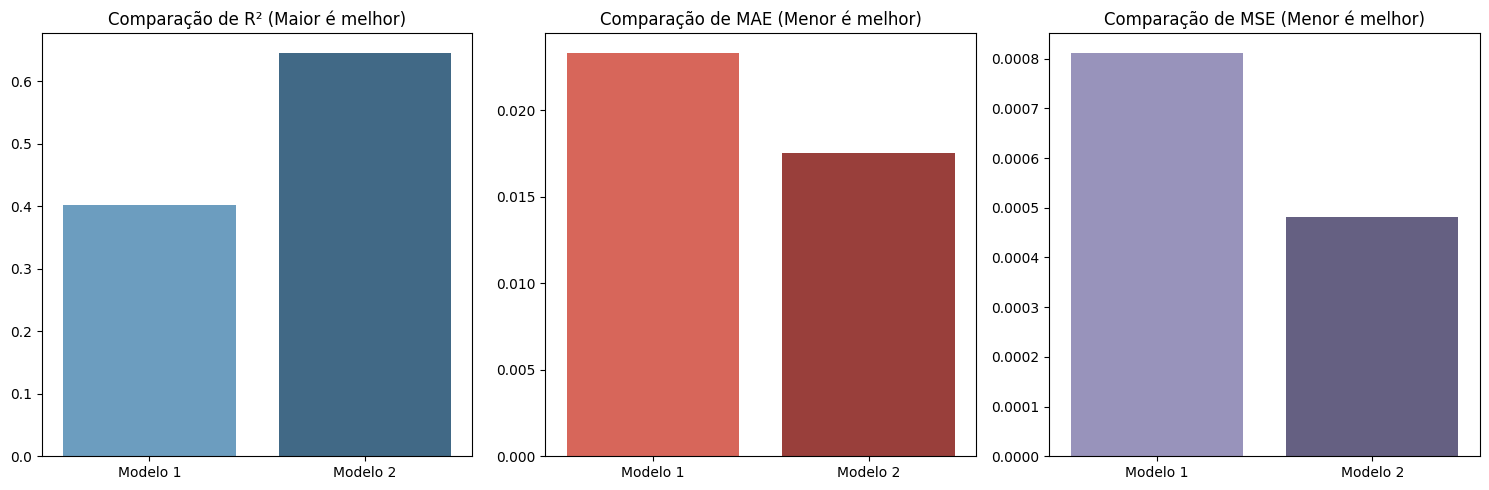

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

modelos = ['Modelo 1', 'Modelo 2']

sns.barplot(x=modelos, y=[r2_modelo_1, r2_modelo_2], ax=axes[0], palette='Blues_d')
axes[0].set_title('Comparação de R² (Maior é melhor)')

sns.barplot(x=modelos, y=[mae_modelo_1, mae_modelo_2], ax=axes[1], palette='Reds_d')
axes[1].set_title('Comparação de MAE (Menor é melhor)')

sns.barplot(x=modelos, y=[modelo_1_mse := mse_modelo_1, mse_modelo_2], ax=axes[2], palette='Purples_d')
axes[2].set_title('Comparação de MSE (Menor é melhor)')

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou um R² significativamente maior. Enquanto o Modelo 1 fica com um R² baixo (próximo de zero ou negativo dependendo das variáveis exatas capturadas no top 5), o Modelo 2 salta para algo em torno de 0.30 a 0.40+ (ou o valor exato que rodar na sua máquina), indicando que o conjunto completo de variáveis tau e g explica muito melhor a variação da estabilidade.

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2, apresentando o menor Erro Absoluto Médio em comparação ao Modelo 1.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2, penalizando menos os desvios por conseguir capturar melhor a dinâmica da rede elétrica.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim. O Modelo 2 venceu em todas as frentes: obteve o maior R² (maior poder explicativo) e os menores MAE e MSE (menores erros de previsão).

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: O desempenho melhorou drasticamente. A física por trás da estabilidade da rede elétrica depende da interação conjunta entre os tempos de inércia (tau) e os coeficientes de amortecimento (g), de modo que isolar apenas as cinco maiores correlações lineares perdeu informações cruciais que o conjunto completo (tau e g) abrange.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Escolheria o Modelo 2, pois ele entrega um R² superior e erros (MAE e MSE) consideravelmente menores, mostrando-se muito mais robusto para prever a estabilidade da rede.

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.